# The ring scenario

`N` aircraft start on a circle. Each aircraft flies to the point on the opposite side. Thus every
track goes through the centre, and all the conflicts arrive at the centre at approximately the same
time. This is the arranged worst case, and it is the scenario that shows what happens when one
resolution changes the geometry for all the other aircraft.

The geometry is deterministic. `draw` ignores its generator, so each encounter has the same start
positions. Only the CNS noise changes between the encounters. Thus a difference between two
encounters comes from the noise alone.

This notebook has four parts:

1. The geometry, drawn from 100 encounters.
2. The stop rule. Each run ends when the aircraft reach their waypoints.
3. The three metrics against the fleet size, with plain Monte Carlo.
4. Monte Carlo against the interacting particle system, on the same configuration.

In [1]:
%matplotlib inline
import dataclasses
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed

plt.rcParams["figure.dpi"] = 130

from opencdarr import GnssNavigation, M600, MVP, PastCPA, StateBased, geo
from opencdarr.cns.stack import CnsStreams
from opencdarr.config import load_config
from opencdarr.estimator import agents_for, combine_ipr, estimate_ipr_over
from opencdarr.fleet import FleetStreams, build_env, los_counts, run_fleet
from opencdarr.ips import Particle, estimate_rare_prob, ladder_from_record
from opencdarr.rng import children, generator, root_seed_sequence, spawn
from opencdarr.scenario import CrossingRing

BLUE, RED, ORANGE, PURPLE, GREY = "#1f77b4", "#d62728", "#ff7f0e", "#9467bd", "0.45"
JOBS = 8
SEED = 20260805
RADIUS = 2500.0        # large enough that the noise, not the geometry, drives the losses
STOP_WITHIN = 50.0     # the run ends when every aircraft is this close to its waypoint
POS_CI95 = 15.0        # the GNSS accuracy for the fleet-size sweep

BASE = load_config("../../configs/pairwise.yaml")
RPZ = BASE.conflict.rpz

SITE_IMG = Path.home() / "Projects/opencdarr.github.io/docs/assets/img"


def publish(fig, name: str) -> None:
    if SITE_IMG.is_dir():
        fig.savefig(SITE_IMG / f"{name}.png", dpi=130)


def config(pos_ci95: float, n_encounters: int):
    """One cell of the sweep. `done_timeout` is disabled, so only the waypoints end a run."""
    return dataclasses.replace(
        BASE, seed=SEED, n_encounters=n_encounters,
        scenario=dataclasses.replace(BASE.scenario, speed=10.0,
                                     pos_ci95=pos_ci95, vel_ci95=pos_ci95 / 10.0),
        simulation=dataclasses.replace(BASE.simulation, t_max=1800.0,
                                       done_timeout=1e9, stop_within=STOP_WITHIN),
    )


print(f"ring radius {RADIUS:.0f} m   rpz {RPZ:.0f} m   "
      f"lookahead {BASE.conflict.t_lookahead:.0f} s   stop_within {STOP_WITHIN:.0f} m")

ring radius 2500 m   rpz 50 m   lookahead 120 s   stop_within 50 m


## Part 1 — what one hundred encounters look like

The first figure is the scenario itself. There is one column for each fleet size in the sweep, and
each column shows the ground tracks of 100 encounters. The start positions are the same in each
encounter, so the spread between the tracks is the effect of the GNSS noise on the resolution.

The top row is the full ring. The bottom row is the centre, where the tracks pass the protected
zone. More aircraft give more tracks through the same centre, and the resolution must open a gap
for each pair at approximately the same time.

In [2]:
def fly_one(seq, n_ac: int, pos_ci95: float):
    """One recorded encounter — the states log, for the ground tracks."""
    cfg = config(pos_ci95, 1)
    sc = CrossingRing(n=n_ac, radius=RADIUS)
    fleet = sc.draw(generator(seq), cfg)
    agents = agents_for(fleet, M600)
    nav, _, _ = spawn(seq, 3)
    return run_fleet(
        agents, rpz=cfg.conflict.rpz, t_lookahead=cfg.conflict.t_lookahead,
        dt=cfg.simulation.dt, detector=StateBased(), resolver=MVP(1.05), recovery=PastCPA(),
        navigation=GnssNavigation(), rng=generator(nav), t_max=cfg.simulation.t_max,
        done_timeout=cfg.simulation.done_timeout, stop_within=STOP_WITHIN, record=True)


SIZES = [4, 6, 8]
N_SHOW = 100

shown = {}
for n_ac in SIZES:
    t0 = time.perf_counter()
    shown[n_ac] = [fly_one(s, n_ac, POS_CI95)
                   for s in spawn(root_seed_sequence(SEED), N_SHOW)]
    outs = shown[n_ac]
    print(f"N {n_ac}   {N_SHOW} encounters   losses of separation {sum(o.los for o in outs):>3}"
          f"   closest approach overall {min(o.min_sep for o in outs):6.1f} m"
          f"   {time.perf_counter() - t0:5.1f} s")

N 4   100 encounters   losses of separation   0   closest approach overall   59.4 m     7.2 s


N 6   100 encounters   losses of separation   0   closest approach overall   50.3 m    13.1 s


N 8   100 encounters   losses of separation   2   closest approach overall   42.9 m    22.7 s


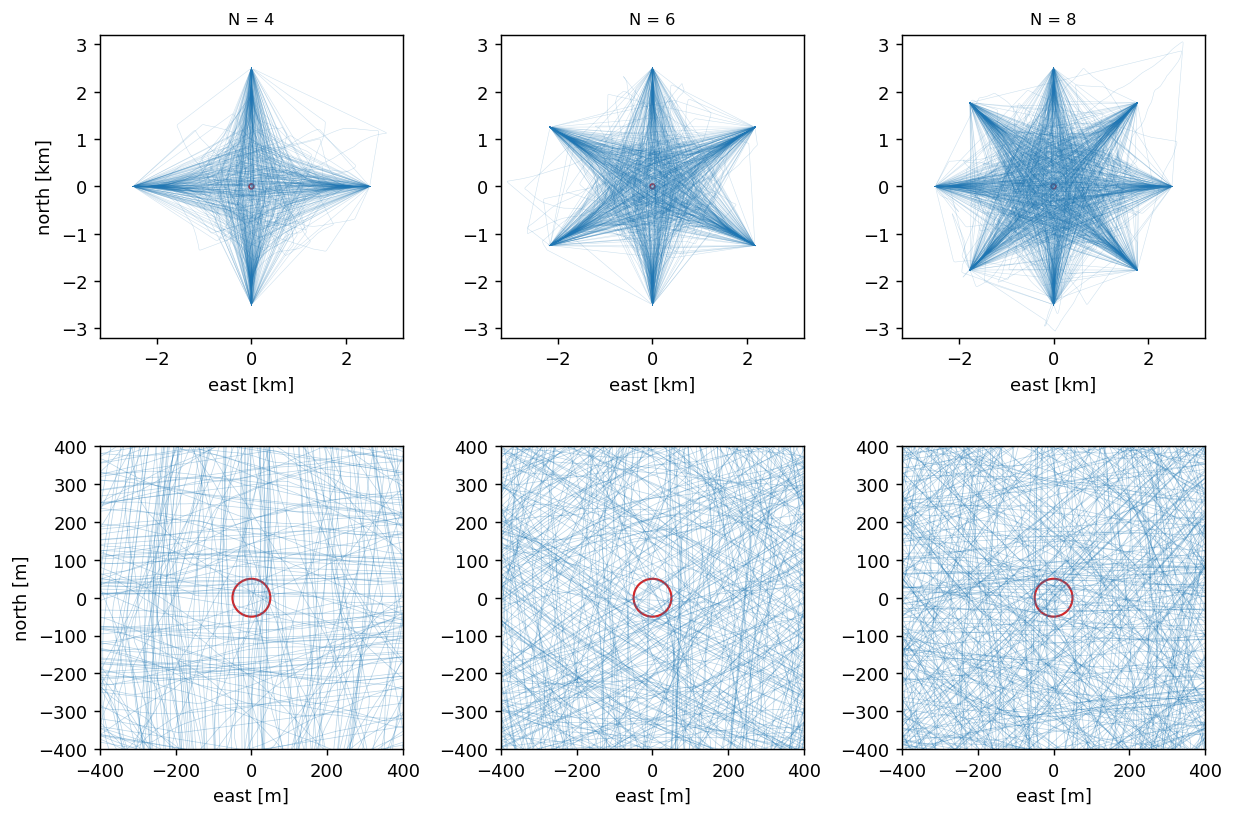

In [3]:
def tracks_enu(outcome):
    """Each aircraft's ground track in metres, relative to the centre of the ring."""
    frames = outcome.frames
    lat0, lon0 = 52.0, 4.0
    out = []
    for i in range(len(frames[0].states)):
        xy = []
        for f in frames:
            qdr, dist = geo.qdrdist(lat0, lon0, f.states[i].lat, f.states[i].lon)
            a = np.radians(qdr)
            xy.append((dist * np.sin(a), dist * np.cos(a)))
        out.append(np.array(xy))
    return out


fig, axes = plt.subplots(2, len(SIZES), figsize=(9.6, 6.6))

for col, n_ac in enumerate(SIZES):
    ax = axes[0, col]
    for outcome in shown[n_ac]:
        for track in tracks_enu(outcome):
            ax.plot(track[:, 0] / 1000, track[:, 1] / 1000, color=BLUE, lw=0.3, alpha=0.22)
    ax.add_patch(plt.Circle((0, 0), RPZ / 1000, color=RED, fill=False, lw=1.0))
    ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
    ax.set_title(f"N = {n_ac}", fontsize=9)
    ax.set_xlabel("east [km]")
    if col == 0:
        ax.set_ylabel("north [km]")
    ax.set_box_aspect(1)

    ax = axes[1, col]
    for outcome in shown[n_ac]:
        for track in tracks_enu(outcome):
            ax.plot(track[:, 0], track[:, 1], color=BLUE, lw=0.4, alpha=0.3)
    ax.add_patch(plt.Circle((0, 0), RPZ, color=RED, fill=False, lw=1.2))
    ax.set_xlim(-400, 400); ax.set_ylim(-400, 400)
    ax.set_xlabel("east [m]")
    if col == 0:
        ax.set_ylabel("north [m]")
    ax.set_box_aspect(1)

fig.tight_layout()
publish(fig, "scenario-ring-tracks")

## Part 2 — the run ends at the waypoints

`stop_within` ends a run when every aircraft is within 50 m of its final waypoint.
`done_timeout` is disabled, so it cannot end a run first. The cell below reports why each of the
100 encounters
stopped, and how long it took.

Without this rule the majority of ring encounters do not terminate on their own. They reach the
`t_max` clock cap while the aircraft loiter at their waypoints, which makes the run length a
property of the cap and not of the scenario.

In [4]:
cfg = config(POS_CI95, 1)
print(f"{'':>4}{'mean [s]':>10}{'min [s]':>9}{'max [s]':>9}"
      f"{'gap to waypoint [m]':>21}{'within 50 m':>13}")
for n_ac in SIZES:
    outs = shown[n_ac]
    durations = np.array([o.frames[-1].t for o in outs])
    fleet = CrossingRing(n=n_ac, radius=RADIUS).draw(generator(root_seed_sequence(SEED)), cfg)
    gaps = np.array([
        geo.qdrdist(ac.lat, ac.lon, goal[0], goal[1])[1]
        for o in outs
        for ac, (_, goal) in zip(o.frames[-1].states, fleet)
    ])
    print(f"N {n_ac:>2}{durations.mean():10.1f}{durations.min():9.1f}{durations.max():9.1f}"
          f"{gaps.mean():21.1f}{100 * (gaps < STOP_WITHIN).mean():12.1f}%")
print(f"\nt_max is {cfg.simulation.t_max:.0f} s. No run reaches it,"
      " so the waypoints end them all.")

      mean [s]  min [s]  max [s]  gap to waypoint [m]  within 50 m
N  4     359.6    299.0    544.0                 11.4       100.0%
N  6     379.4    312.0    573.0                  7.7       100.0%
N  8     404.2    329.0    655.0                  5.9       100.0%

t_max is 1800 s. No run reaches it, so the waypoints end them all.


## Part 3 — the three metrics against the fleet size

The sweep runs `N = 4, 6, 8` at one accuracy. Each cell reports the three quantities:

- $P_{ac}$, the probability for each aircraft. This is the number to quote.
- $P_{run}$, the probability that a run has one loss or more.
- $\mathbb{E}[K]$, the mean number of pairs that lost separation in a run.

The three are the same number at two aircraft. This sweep shows how far they separate as the fleet
grows, and it is the reason the per-aircraft form is the one on the axis.

In [5]:
N_ENC = 20_000


def run_mc(n_ac: int, pos_ci95: float, n_encounters: int):
    cfg = config(pos_ci95, n_encounters)
    sc = CrossingRing(n=n_ac, radius=RADIUS)
    root = root_seed_sequence(cfg.seed)
    bounds = [(i * n_encounters // JOBS, (i + 1) * n_encounters // JOBS) for i in range(JOBS)]
    parts = Parallel(n_jobs=JOBS)(
        delayed(estimate_ipr_over)(sc, cfg, M600, StateBased(), MVP(1.05), PastCPA(),
                                   GnssNavigation(), seqs=children(root, lo, hi))
        for lo, hi in bounds)
    return combine_ipr(parts)


sweep = {}
for n_ac in SIZES:
    t0 = time.perf_counter()
    sweep[n_ac] = run_mc(n_ac, POS_CI95, N_ENC)
    r = sweep[n_ac]
    print(f"N {n_ac}   P_ac {r.p_ac:.5f}   P_run {r.p_los:.5f}   E[K] {r.mean_los_pairs:.5f}   "
          f"events {r.n_los:>4}   {time.perf_counter() - t0:6.1f} s")

N 4   P_ac 0.00032   P_run 0.00065   E[K] 0.00065   events   13    397.1 s


N 6   P_ac 0.00113   P_run 0.00335   E[K] 0.00340   events   67    729.5 s


In [ ]:
fig, ax = plt.subplots(figsize=(4.4, 4.0))
ax.plot(SIZES, [sweep[n].p_ac for n in SIZES], "o-", color=BLUE, label="$P_{ac}$")
ax.plot(SIZES, [sweep[n].p_los for n in SIZES], "s-", color=RED, label="$P_{run}$")
ax.plot(SIZES, [sweep[n].mean_los_pairs for n in SIZES], "^-", color=ORANGE, label="E[K]")
ax.set_xticks(SIZES); ax.set_xlabel("aircraft in the ring")
ax.set_ylabel("value"); ax.set_yscale("log")
ax.set_box_aspect(1); ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
publish(fig, "scenario-ring-metrics")

## Part 4 — Monte Carlo against the interacting particle system

The last part runs the two estimators on the same configuration at `N = 8`. IPS runs with
`tail=True`, so each survivor flies on to the end of its encounter. That tail is what gives the
per-aircraft number, because the splitting alone stops a particle at its first loss of separation.

The shells come from the Monte Carlo record of the same cell.

In [ ]:
def build_initial_for(n_ac: int, pos_ci95: float):
    cfg = config(pos_ci95, 1)
    sc = CrossingRing(n=n_ac, radius=RADIUS)

    def build_initial(seq):
        fleet = sc.draw(generator(seq), cfg)
        agents = agents_for(fleet, M600)
        env = build_env(
            agents, rpz=cfg.conflict.rpz, t_lookahead=cfg.conflict.t_lookahead,
            dt=cfg.simulation.dt, detector=StateBased(), resolver=MVP(1.05),
            recovery=PastCPA(), navigation=GnssNavigation(),
            t_max=cfg.simulation.t_max, done_timeout=cfg.simulation.done_timeout,
            stop_within=cfg.simulation.stop_within,
        )
        return Particle(env=env, state=env.initial_state(agents))

    return build_initial


shells = ladder_from_record(sweep[8].min_seps, RPZ)
t0 = time.perf_counter()
ips8 = estimate_rare_prob(build_initial_for(8, POS_CI95), shells,
                          n_particles=600, reps=8, seed=SEED, tail=True)
print(f"shells {len(shells)}   {shells}")
print(f"IPS  P_run {ips8.prob:.5f}   ci [{ips8.ci[0]:.5f}, {ips8.ci[1]:.5f}]   "
      f"collapsed {ips8.n_collapsed}/8   {time.perf_counter() - t0:6.1f} s")

p_ac_reps = [r.p_ac for r in ips8.reps if r.prob > 0]
lineages = [r.n_lineages for r in ips8.reps]
print(f"IPS  P_ac  {np.mean(p_ac_reps):.5f}   from {len(p_ac_reps)} replications")
print(f"     distinct lineages per replication: {lineages}")
print(f"MC   P_run {sweep[8].p_los:.5f}   ci95 [{sweep[8].ci95[0]:.5f}, {sweep[8].ci95[1]:.5f}]")
print(f"MC   P_ac  {sweep[8].p_ac:.5f}")
if sweep[8].p_los > 0 and sweep[8].p_ac > 0:
    print(f"\nratio IPS/MC on P_run {ips8.prob / sweep[8].p_los:.2f}   "
          f"on P_ac {np.mean(p_ac_reps) / sweep[8].p_ac:.2f}")
else:
    print("\nMonte Carlo saw no loss of separation in this cell, so there is no ratio. "
          "Increase N_ENC until it sees approximately 50 events.")

## What this shows

The ring is the arranged worst case, so it is the scenario in which the three metrics separate
the most. $P_{run}$ grows with the fleet size because more pairs can fail, not because the
airspace is
more dangerous for one aircraft. $P_{ac}$ removes that growth, and $\mathbb{E}[K]$ keeps the
multiplicity that $P_{run}$ discards.

The two estimators agree on the same configuration. The per-aircraft number from IPS needs the tail
leg, and its precision comes from the number of distinct lineages, not from the number of
particles.